In [36]:
from isochrones.mist import MIST_Isochrone
from isochrones.mist import MISTIsochroneGrid
from isochrones.interp import DFInterpolator
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import itertools
from scipy.optimize import brentq

In [37]:
df = pd.DataFrame()
grid = MISTIsochroneGrid()
mist = MIST_Isochrone()

In [86]:
subset = grid.df.xs((9.3, 0.0), level=('log10_isochrone_age_yr', 'feh'))
subset.head(10)

,eep,age,feh,mass,initial_mass,radius,density,logTeff,Teff,logg,logL,Mbol,delta_nu,nu_max,phase,dm_deep
EEP,,,,,,,,,,,,,,,,
206,206,9.3,0.042969,0.100000,0.100000,0.126150,70.223955,3.460248,2885.676185,5.236368,-3.002587,12.246468,1045.952034,27562.039894,0.0,0.002529
207,207,9.3,0.042979,0.102528,0.102529,0.128343,68.372114,3.462014,2897.435751,5.230306,-2.980555,12.191388,1031.226858,27184.044399,0.0,0.003298
208,208,9.3,0.042996,0.106596,0.106596,0.131950,65.412481,3.464855,2916.454479,5.220555,-2.945114,12.102784,1007.540774,26576.027768,0.0,0.004270
209,209,9.3,0.043015,0.111069,0.111069,0.136035,62.200377,3.467981,2937.518638,5.209828,-2.906131,12.005328,981.488265,25907.244590,0.0,0.004374
210,210,9.3,0.043034,0.115343,0.115343,0.140056,59.189041,3.470967,2957.788925,5.199581,-2.868884,11.912211,956.598206,25268.315517,0.0,0.004216
211,211,9.3,0.043054,0.119500,0.119500,0.144080,56.325981,3.473872,2977.640219,5.189615,-2.832658,11.821645,932.392506,24646.968772,0.0,0.004311
212,212,9.3,0.043077,0.123965,0.123966,0.148531,53.333042,3.476993,2999.113892,5.178911,-2.793746,11.724365,906.394492,23979.620639,0.0,0.004392
213,213,9.3,0.043100,0.128285,0.128285,0.152969,50.526583,3.480013,3020.038994,5.168556,-2.756100,11.630249,881.244773,23334.062749,0.0,0.004266
214,214,9.3,0.043123,0.132497,0.132498,0.157423,47.879985,3.482957,3040.587326,5.158460,-2.719388,11.538471,856.723061,22704.643346,0.0,0.004354


In [87]:
# view of a subset of the isochrones
subset = grid.df.xs((9.6, 0.0, 350), level=('log10_isochrone_age_yr', 'feh', 'EEP'))
subset.head(50)

,,,eep,age,feh,mass,initial_mass,radius,density,logTeff,Teff,logg,logL,Mbol,delta_nu,nu_max,phase,dm_deep
log10_isochrone_age_yr,feh,EEP,,,,,,,,,,,,,,,,
9.6,0.0,350,350,9.6,-0.015224,1.009054,1.009197,1.019003,1.344433,3.76829,5865.290644,4.425688,0.044155,4.629613,138.621965,2990.058765,0.0,0.008206


In [72]:
idx = pd.IndexSlice

subset = grid.df.loc[
    idx[9.6, 0.0, 330:400],
    :
]

subset = subset[(subset['mass'] >= 0.98) & (subset['mass'] <= 1.02)]
subset

eep  age       feh      mass  initial_mass  \
log10_isochrone_age_yr feh EEP                                               
9.6                    0.0 348  348  9.6 -0.010323  0.990534      0.990663   
                           349  349  9.6 -0.012815  1.000889      1.001025   
                           350  350  9.6 -0.015224  1.009054      1.009197   
                           351  351  9.6 -0.017757  1.017287      1.017436   

                                  radius   density   logTeff         Teff  \
log10_isochrone_age_yr feh EEP                                              
9.6                    0.0 348  0.986014  1.456707  3.763613  5802.472342   
                           349  1.004231  1.393274  3.766278  5838.188124   
                           350  1.019003  1.344433  3.768290  5865.290644   
                           351  1.034425  1.295681  3.770295  5892.435695   

                                    logg      logL      Mbol    delta_nu  \
log10_isochrone_age_yr feh EEP                                             
9.6                    0.0 348  4.446228 -0.003136  4.747840  144.210254   
                           349  4.434861  0.023425  4.681437  141.075955   
                           350  4.425688  0.044155  4.629613  138.621965   
                           351  4.416183  0.065223  4.576943  136.117697   

                                     nu_max  phase   dm_deep  
log10_isochrone_age_yr feh EEP                                
9.6                    0.0 348  3151.947587    0.0  0.010476  
                           349  3060.650700    0.0  0.009267  
                           350  2990.058765    0.0  0.008206  
                           351  2918.392949    0.0  0.007399

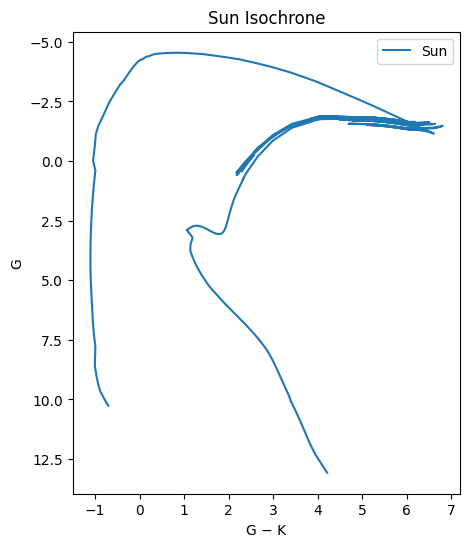

In [42]:
iso_sun = mist.isochrone(9.6, 0.0)  

plt.figure(figsize=(5,6))

plt.plot(
    iso_sun['G_mag'] - iso_sun['K_mag'],
    iso_sun['G_mag'],
    label='Sun'
)

plt.gca().invert_yaxis()
plt.xlabel('G − K')
plt.ylabel('G')
plt.title('Sun Isochrone')
plt.legend()
plt.show()

In [31]:
interp = DFInterpolator(grid.df)

# Mass as a function of EEP
def mass_at_eep(eep, logage, feh):
    return interp(
        [logage, feh, eep],
        cols=["mass"]
    )[0]

In [34]:
mass_at_eep(250, 9.6, 0.0)

0.29421364499508723

In [68]:
iso = mist.isochrone(5.0, -4.0)

In [69]:
iso.columns

Index(['eep', 'age', 'feh', 'mass', 'initial_mass', 'radius', 'density',
       'logTeff', 'Teff', 'logg', 'logL', 'Mbol', 'delta_nu', 'nu_max',
       'phase', 'dm_deep', 'J_mag', 'H_mag', 'K_mag', 'G_mag', 'BP_mag',
       'RP_mag', 'W1_mag', 'W2_mag', 'W3_mag', 'TESS_mag', 'Kepler_mag'],
      dtype='object')

In [70]:
chosen_mass = 4.241212295503883
star = iso.iloc[(iso['mass'] - chosen_mass).abs().argmin()]

# This returns the MIST model point whose mass is closest to the mass chosen

J_mag = star['J_mag']
H_mag = star['H_mag']
K_mag = star['K_mag']
G_mag = star['G_mag']

print(f'J_mag : {J_mag}, H_mag : {H_mag}, K_mag : {K_mag}, G_mag : {G_mag}')

J_mag : -2.2814228587069705, H_mag : -2.3524524969284486, K_mag : -2.3651375286361, G_mag : -1.991110110013969


In [73]:
def get_magnitudes(eep, logage, feh):
    mass = mass_at_eep(eep, logage, feh)
    star = iso.iloc[(iso['mass'] - mass).abs().argmin()]

    J_mag = star['J_mag']
    H_mag = star['H_mag']
    K_mag = star['K_mag']
    G_mag = star['G_mag']

    print(f'J_mag : {J_mag}, H_mag : {H_mag}, K_mag : {K_mag}, G_mag : {G_mag}')

In [74]:
get_magnitudes(132, 5.0, -4.0)

J_mag : -2.2814228587069705, H_mag : -2.3524524969284486, K_mag : -2.3651375286361, G_mag : -1.991110110013969
